# **3.7.1 Project Networks and Critical Paths**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/19eBLGKTWLkujcjn_FshdABbb8S9HhFeF?usp=sharing)

A project network provides a graphical representation of the precedence relations among all the activities in a project. Each activity is represented by an arc in the network. The nodes in the network denote **events** corresponding to points in time when one or more activities are completed. Directions on the arcs indicate the sequence in which events must occur. Additionally, a node is added at the beginning of the network to represent the *start* event for the entire project. Similarly, a final node is introduced to denote the *finish* event for the project.

&nbsp;&nbsp;&nbsp;&nbsp;As an illustration, we will build a project network for a set of six activities with the following precedence constraints:

&nbsp;&nbsp;&nbsp;&nbsp;1. A precedes D  
&nbsp;&nbsp;&nbsp;&nbsp;2. A and B precede C  
&nbsp;&nbsp;&nbsp;&nbsp;3. C and D precede F  
&nbsp;&nbsp;&nbsp;&nbsp;4. E precedes F  

<br>

<div align="center">

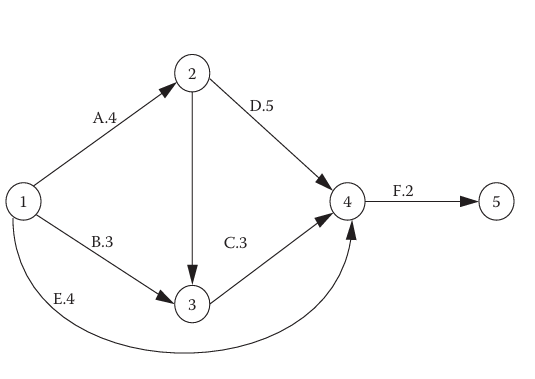

</div>

<br>

**Figure 3.21**  
Project network.

The project network diagram is shown in **Figure 3.21**. Solid arcs denote activities A through E. Activities C, D, and E must all precede activity F. Therefore, we use event 4 to represent the time at which activities C, D, and E are all finished, and activity F can begin. We cannot combine events 2 and 3. We want event 2 to represent that A has finished and D can begin. Event 3 represents that A and B are finished and C can begin. To do this, we introduce a dummy activity from event 2 to event 3 with zero duration. The sole purpose of this is to ensure that event C does not start until event A has finished.

&nbsp;&nbsp;&nbsp;&nbsp;We let the variable $t_i$ represent the time at which event $i$ occurs, and $d_{ij}$ denote the duration of the activity represented by the arc between nodes $i$ and $j$. In this example, suppose $d_{12} = 4$, $d_{13} = 3$, $d_{14} = 4$, $d_{23} = 0$, $d_{24} = 5$, $d_{34} = 3$, and $d_{45} = 2$. These individual activity lengths are shown in **Figure 3.21** along the appropriate arcs. Since $t_1$ and $t_5$ are the *start* and *finish* times, total project length is $(t_5 - t_1)$.

&nbsp;&nbsp;&nbsp;&nbsp;Now that the activities have been identified and described in the diagram, our next objective is to determine a minimum length project schedule; that is, to determine when each activity should begin so that precedence constraints are met and the entire project completes as quickly as possible. We can write the formulation as a linear programming problem, with constraints to assure that successive events $i$ and $j$ are separated from one another by at least the required duration of the event on the arc $(i, j)$:

$$
\begin{aligned}
\text{minimize} \qquad & z = t_5 - t_1 \\[6pt]
\text{subject to} \qquad & t_2 - t_1 \geq 4 \\
& t_3 - t_1 \geq 3 \\
& t_4 - t_1 \geq 4 \\
& t_3 - t_2 \geq 0 \\
& t_4 - t_2 \geq 5 \\
& t_4 - t_3 \geq 3 \\
& t_5 - t_4 \geq 2 \\
& t_i \geq 0 \qquad \text{for all } i = 1, 2, \ldots, 5
\end{aligned}
$$

Note that this formulation could be solved with the ordinary Simplex method, but clearly there is a special network structure to the problem.

&nbsp;&nbsp;&nbsp;&nbsp;In order to minimize the project duration, we have to realize that actually we must find the longest sequence of linearly ordered activities; that is, we must find the **longest path** through the network. This insight gives us a slightly different perspective on the problem.

&nbsp;&nbsp;&nbsp;&nbsp;Consider the following linear programming problem. Let $x_{ij} = 1$ if activity $(i, j)$ is in the longest path, and $x_{ij} = 0$ otherwise. This problem can be written as:

$$
\begin{aligned}
\text{maximize} \qquad & 4x_{12} + 3x_{13} + 4x_{14} + 5x_{24} + 3x_{34} + 2x_{45} \\[6pt]
\text{subject to} \qquad
& -x_{12} - x_{13} - x_{14} = -1 \\
& x_{12} - x_{23} - x_{24} = 0 \\
& x_{13} + x_{23} - x_{34} = 0 \\
& x_{14} + x_{24} + x_{34} - x_{45} = 0 \\
& x_{45} = 1 \\[6pt]
& \text{all } x_{ij} = 0 \text{ or } 1
\end{aligned}
$$

The objective function adds up the total length of the longest path, while the constraints ensure that the solution represents a path from event 1 to event 5. The first constraint states that only one edge can leave node 1. The last constraint states that only one edge can enter node 5. The other constraints specify that the number of incoming arcs equals the number of outgoing arcs in each of the interior nodes. The only feasible solution to this problem is a path, and the optimal solution is the longest path.

&nbsp;&nbsp;&nbsp;&nbsp;These two problems are in fact equivalent. The second one is called the dual problem of the first. Recall from the discussion in **Section 2.8** that every linear programming problem has a dual problem, and typically the two versions represent a different view or interpretation of the same problem parameters. Notice that the first problem has one constraint for each activity and one variable for each event, while the second formulation has a constraint for each event and a variable for each activity.

&nbsp;&nbsp;&nbsp;&nbsp;If we inspect the previous dual formulation, we can see that the constraints require that one *unit of flow* is to be routed from node 1 to node 5. We now recognize that this is the specialized form of the transshipment model that we dealt with in **Section 3.5** to find the shortest path through a network. In our project management application, however, we minimize project duration by maximizing the path length. We can therefore treat our project scheduling problem as a *longest path* problem.

&nbsp;&nbsp;&nbsp;&nbsp;By finding the longest path through the project network, we are also finding what is known as the *critical path*. A **critical path** is a path from the start node to the finish node, with the property that any delay in completing activities along this path will cause a delay in overall project completion. The activities along the critical path are called **critical activities**.

&nbsp;&nbsp;&nbsp;&nbsp;To describe the PERT-CPM method for identifying critical activities in a project, we need two definitions. The **earliest time** for a node $j$, denoted $E_j$, is the time at which event $j$ will occur if all previous activities are started as early as possible. The *start* node 1 has $E_1 = 0$ since there are no predecessors. Then any other node’s earliest time can be determined as long as all its predecessors’ earliest times have been calculated. We can make a **forward pass** through the network, calculating $E_j$ for each event $j$ as

<br>

$$
E_j = \max_i \{E_i + d_{ij}\}
$$

<br>

where $(i, j)$ are all the arcs entering node $j$, and $d_{ij}$ is the duration of the activity represented by arc $(i, j)$. Once we have the earliest time for the *finish* event, we know the earliest possible completion time for the entire project.

&nbsp;&nbsp;&nbsp;&nbsp;The **latest time** for a node $i$, denoted $L_i$, is the latest time that event $i$ can occur without causing delay in the completion of the project beyond its earliest possible time. Once we have made the forward pass to determine the earliest project completion time, we make a **backward pass** through the network. For a network of $n$ nodes, $L_n = E_n$, then $L_i$ can be determined for any node $i$ as long as all of that node’s successors’ latest times have been calculated. The general formula is

<br>

$$
L_i = \min_j \{L_j - d_{ij}\}
$$

where $(i, j)$ are all the arcs leaving node $i$.

&nbsp;&nbsp;&nbsp;&nbsp;The **slack time for an event** is the difference between the latest time and the earliest time for that event. Events having a slack time of zero are called **critical events**. The **slack time of an activity** $(i, j)$ is $L_j - E_i - d_{ij}$. Activities with slack time zero are the **critical activities**, which must be completed without delay if the minimum feasible project duration is to be achieved.

&nbsp;&nbsp;&nbsp;&nbsp;Now re-examine the project network in **Figure 3.21** to determine a critical path and construct a time chart. During the forward pass, we obtain the following earliest times:

$$
\begin{array}{l}
E_1 = 0 \\[8pt]
E_2 = \displaystyle \max_{1}\{0 + 4\} = 4 \\[8pt]
E_3 = \displaystyle \max_{1,2}\{0 + 3, 4 + 0\} = 4 \\[8pt]
E_4 = \displaystyle \max_{1,2,3}\{4 + 5, 4 + 3, 0 + 4\} = 9 \\[8pt]
E_5 = \displaystyle \max_{4}\{9 + 2\} = 11
\end{array}
$$
Therefore, the minimum completion time for the project is 11 time units. In a backward pass, we obtain latest times for each event as follows:

$$
\begin{array}{l}
L_5 = E_5 = 11 \\[8pt]
L_4 = \displaystyle \min_{5}\{11 - 2\} = 9 \\[8pt]
L_3 = \displaystyle \min_{4}\{9 - 3\} = 6 \\[8pt]
L_2 = \displaystyle \min_{3,4}\{6 - 0, 9 - 5\} = 4 \\[8pt]
L_1 = \displaystyle \min_{2,3,4}\{4 - 4, 6 - 3, 9 - 4\} = 0
\end{array}
$$

<br>

From these results, we can determine the critical path. Since $E_1 = L_1$, $E_2 = L_2$, $E_4 = L_4$, and $E_5 = L_5$, the critical events are at nodes 1, 2, 4, and 5; and therefore the critical activities are activities A, D, and F, the activities along the critical path. We also notice that the slack times for the activities are

<br>

**Table 3.21** <br>
Project Time Chart

<div align="center">

| Activity | Duration | Earliest Start | Latest Start | Earliest Finish | Latest Finish | Slack Time |
|---|---:|---:|---:|---:|---:|---:|
| A | 4 | 0 | 0 | 4 | 4 | 0 |
| B | 3 | 0 | 1 | 3 | 4 | 3 |
| C | 3 | 4 | 6 | 7 | 9 | 2 |
| D | 5 | 4 | 4 | 9 | 9 | 0 |
| E | 4 | 0 | 5 | 4 | 9 | 5 |
| F | 2 | 9 | 9 | 11 | 11 | 0 |

</div>

<br>

activities A, D, and F (the activities along the critical path). We also notice that the slack times for the activities are

<br>

$$
\text{A: } L_2 - E_1 - 4 = 4 - 0 - 4 = 0
$$

$$
\text{B: } L_3 - E_1 - 3 = 6 - 0 - 3 = 3
$$

$$
\text{C: } L_4 - E_3 - 3 = 9 - 4 - 3 = 2
$$

$$
\text{D: } L_4 - E_2 - 5 = 9 - 4 - 5 = 0
$$

$$
\text{E: } L_4 - E_1 - 4 = 9 - 0 - 4 = 5
$$

$$
\text{F: } L_5 - E_4 - 2 = 11 - 9 - 2 = 0
$$

<br>

and the activities with zero slack time are the critical activities. The noncritical activities B, C, and E could be delayed as much as 3, 2, and 5 time units, respectively, without extending the duration of the project.

&nbsp;&nbsp;&nbsp;&nbsp;All of this information can be summarized in the time chart shown in **Table 3.21**. This layout provides a clear and convenient tool for management to use in scheduling noncritical activities, considering possible improvements in the project schedule, or in evaluating the effects of delays along the critical path.


**Code Implementation**

In [ ]:
# ========================================
# 3.7.1 Project Networks and Critical Paths
# PERT/CPM Forward Pass, Backward Pass, and Slack Times
# ========================================

import pandas as pd

# Activities from Figure 3.21
# Format: Activity: (start_node, finish_node, duration)
activities = {
    "A": (1, 2, 4),
    "B": (1, 3, 3),
    "C": (3, 4, 3),
    "D": (2, 4, 5),
    "E": (1, 4, 4),
    "F": (4, 5, 2)
}

nodes = [1, 2, 3, 4, 5]

# ----------------------------
# Forward pass: earliest event times
# ----------------------------
E = {node: 0 for node in nodes}

for node in nodes:
    for activity, (start, finish, duration) in activities.items():
        if start == node:
            E[finish] = max(E[finish], E[start] + duration)

print("Earliest Event Times:")
for node in nodes:
    print(f"E{node} = {E[node]}")

# ----------------------------
# Backward pass: latest event times
# ----------------------------
project_duration = E[5]

L = {node: project_duration for node in nodes}
L[5] = project_duration

for node in reversed(nodes):
    outgoing = [
        (finish, duration)
        for activity, (start, finish, duration) in activities.items()
        if start == node
    ]

    if outgoing:
        L[node] = min(L[finish] - duration for finish, duration in outgoing)

print("\nLatest Event Times:")
for node in nodes:
    print(f"L{node} = {L[node]}")

# ----------------------------
# Activity time chart
# ----------------------------
rows = []

for activity, (start, finish, duration) in activities.items():
    earliest_start = E[start]
    earliest_finish = earliest_start + duration
    latest_start = L[finish] - duration
    latest_finish = L[finish]
    slack = latest_start - earliest_start

    rows.append({
        "Activity": activity,
        "Duration": duration,
        "Earliest Start": earliest_start,
        "Latest Start": latest_start,
        "Earliest Finish": earliest_finish,
        "Latest Finish": latest_finish,
        "Slack Time": slack
    })

time_chart = pd.DataFrame(rows)

print("\nProject Time Chart:")
display(time_chart)

# ----------------------------
# Critical activities
# ----------------------------
critical_activities = time_chart[time_chart["Slack Time"] == 0]["Activity"].tolist()

print("Critical Activities:", critical_activities)
print("Critical Path:", " → ".join(critical_activities))
print("Project Duration:", project_duration, "time units")

Earliest Event Times:
E1 = 0
E2 = 4
E3 = 3
E4 = 9
E5 = 11

Latest Event Times:
L1 = 0
L2 = 4
L3 = 6
L4 = 9
L5 = 11

Project Time Chart:


,Activity,Duration,Earliest Start,Latest Start,Earliest Finish,Latest Finish,Slack Time
0,A,4,0,0,4,4,0
1,B,3,0,3,3,6,3
2,C,3,3,6,6,9,3
3,D,5,4,4,9,9,0
4,E,4,0,5,4,9,5
5,F,2,9,9,11,11,0


Critical Activities: ['A', 'D', 'F']
Critical Path: A → D → F
Project Duration: 11 time units
